# All-or-none model simulations

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln
from collections import Counter
import networkx as nx

## Model and analytical formulae

`model(N, p)` grows a network of $N$ nodes. At each step a new node connects to a uniformly random target $u$, then to all neighbours of $u$ with probability $p$ or none with probability $1-p$.

In [6]:
def model(N, p):
    G = nx.Graph()
    G.add_node(0)
    for t in range(1, N):
        u = np.random.randint(0, t) 
        G.add_edge(t, u)
        if np.random.random() < p:
            for w in list(G.neighbors(u)):
                if w != t:
                    G.add_edge(t, w)
    return G

The theory functions implement the exact formulae derived in the paper. Gamma functions are computed in log-space via `gammaln` for numerical stability.

In [20]:
# Homogeneous solutions
def A(N, p):
    return np.exp(gammaln(N + 2 * p) - gammaln(1 + 2 * p) - gammaln(N))

def B(N, p):
    return np.exp(gammaln(N + 3 * p) - gammaln(1 + 3 * p) - gammaln(N))

def C_hom(N, p):
    return np.exp(gammaln(N + 4 * p) - gammaln(1 + 4 * p) - gammaln(N))

# Expected number of edges M_n
def M_theory(N, p):
    return (N - A(N, p)) / (1 - 2 * p)

# Expected number of triangles T_n
def T_theory(N, p):
    return (2 * p * N / ((1 - 2 * p) * (1 - 3 * p)) + 2 * A(N, p) / (1 - 2 * p) - 2 * B(N, p) / (1 - 3 * p))

# Degree distribution P_k
def Pk_theory(k, p):
    logP = (np.log(1 - p) - np.log(2 + p) + gammaln(k + 1 + 1 / p) - gammaln(2 + 1 / p) + gammaln(2 + 2 / p) - gammaln(k + 1 + 2 / p))
    return np.exp(logP)

# Average shortest-path distance
def ell_theory(N, p):
    H = np.cumsum(1.0 / np.arange(1, N + 2))
    HN = H[N - 1]
    HN1 = H[N]
    gamma = 2 * (2 * p - 1) * (HN - 1) + 2 * (2 - 3 * p) * (HN1 - 1.5)
    return gamma * (N + 1) / (N - 1)

## Number of edges vs $p$

Simulated mean edge count (as a function of $p$) vs the prediction

$$M_N = \frac{N - \mathcal{A}_N}{1-2p}, \quad \mathcal{A}_N = \frac{\Gamma(N+2p)}{\Gamma(1+2p)\,\Gamma(N)}.$$

$N \in \{50, 200, 1000\}$, 40 values of $p \in [0.01, 0.95]$, 2000 trials each. Plot is log-scaled on the $y$-axis.

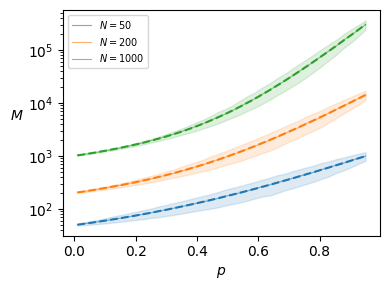

In [ ]:
Ns = [50, 200, 1000]
ps = np.linspace(0.01, 0.95, 40)
trials = 2000

fig, ax = plt.subplots(figsize=(4, 3))

all_means = []
for i, N in enumerate(Ns):
    means, stds = [], []
    for p in ps:
        edges = [model(N, p).number_of_edges() for _ in range(trials)]
        means.append(np.mean(edges))
        stds.append(np.std(edges))
    means, stds = np.array(means), np.array(stds)
    all_means.append((means, stds))

    ax.fill_between(ps, means - stds, means + stds, color=f'C{i}', alpha=0.15)
    ax.plot(ps, means, '-', color=f'C{i}', lw=0.8, alpha=0.6, label=f'$N={N}$')

pp = np.linspace(0.01, 0.95, 200)
for i, N in enumerate(Ns):
    ax.plot(pp, [M_theory(N, p) for p in pp], '--', color=f'C{i}', lw=1.5)

ax.set_xlabel('$p$')
ax.set_ylabel('$M$', rotation=0, labelpad=8)
ax.set_yscale('log')
ax.legend(fontsize=7, loc='upper left')
plt.tight_layout()
fig.savefig('figures/edges_vs_p.pdf')
plt.show()

## Degree distribution (sparse regime, $p < 1/2$)

Empirical degree histogram (as a function of $k$) vs the prediction

$$P_k = \frac{(1-p)\,\Gamma(2+2/p)}{(2+p)\,\Gamma(2+1/p)} \cdot \frac{\Gamma(k+1+1/p)}{\Gamma(k+1+2/p)} \sim k^{-1/p}.$$

$N = 10000$, $p \in \{0.1, 0.2, 0.3, 0.4\}$, 200 trials each. Plot is log-log scaled.

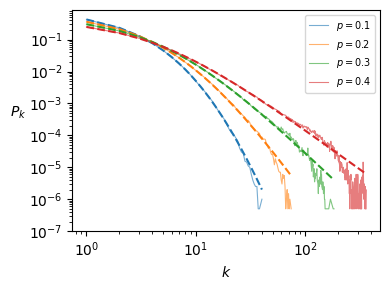

In [22]:
N = 10000
ps = [0.1, 0.2, 0.3, 0.4]
trials = 200

fig, ax = plt.subplots(figsize=(4, 3))

all_data = {}
for p in ps:
    degs = Counter()
    for _ in range(trials):
        G = model(N, p)
        for _, d in G.degree():
            degs[d] += 1
    total = sum(degs.values())
    ks = sorted(degs.keys())
    Psim = [degs[k] / total for k in ks]
    all_data[p] = (ks, Psim)
    ax.plot(ks, Psim, '-', lw=0.8, alpha=0.6, label=f'$p={p}$')

for i, p in enumerate(ps):
    karr = np.arange(1, max(all_data[p][0]) + 1)
    ax.plot(karr, [Pk_theory(k, p) for k in karr], '--', color=f'C{i}', lw=1.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$k$')
ax.set_ylabel('$P_k$', rotation=0, labelpad=8)
ax.set_ylim(bottom=1e-7)
ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig('figures/degree_distribution.pdf')
plt.show()

## Triangles

Simulated mean triangle count (as a function of $p$) vs the prediction

$$T_N = \frac{2pN}{(1-2p)(1-3p)} + \frac{2\mathcal{A}_N}{1-2p} - \frac{2\mathcal{B}_N}{1-3p}, \quad \mathcal{B}_N = \frac{\Gamma(N+3p)}{\Gamma(1+3p)\,\Gamma(N)}.$$

$N \in \{50, 200, 500\}$, 40 values of $p \in [0.01, 0.95]$, 1000 trials each. Plot is log-scaled on the $y$-axis.

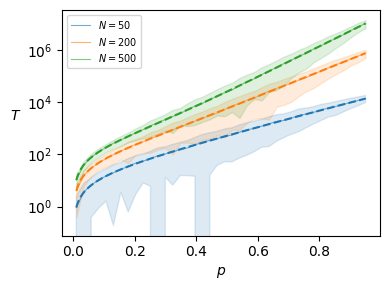

In [10]:
Ns = [50, 200, 500]
ps = np.linspace(0.01, 0.95, 40)
trials = 1000

fig, ax = plt.subplots(figsize=(4, 3))

for i, N in enumerate(Ns):
    means, stds = [], []
    for p in ps:
        tris = []
        for _ in range(trials):
            G = model(N, p)
            tris.append(sum(nx.triangles(G).values()) // 3)
        means.append(np.mean(tris))
        stds.append(np.std(tris))
    means, stds = np.array(means), np.array(stds)

    ax.fill_between(ps, means - stds, means + stds, color=f'C{i}', alpha=0.15)
    ax.plot(ps, means, '-', color=f'C{i}', lw=0.8, alpha=0.6, label=f'$N={N}$')

pp = np.linspace(0.01, 0.95, 250)

for i, N in enumerate(Ns):
    ax.plot(pp, [T_theory(N, p) for p in pp], '--', color=f'C{i}', lw=1.5)

ax.set_xlabel('$p$')
ax.set_ylabel('$T$', rotation=0, labelpad=8)
ax.set_yscale('log')
ax.legend(fontsize=7, loc='upper left')
plt.tight_layout()
fig.savefig('figures/triangles_vs_p.pdf')
plt.show()

## Clustering coefficient

Simulated global clustering coefficient (as a function of $p$) vs the prediction

$$C = \frac{3p}{1+2p}.$$

$N = 500$, 40 values of $p \in [0.02, 0.95]$, 100 trials each.

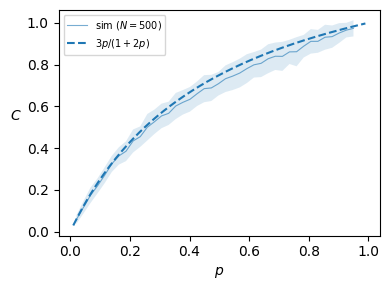

In [11]:
N = 500
ps = np.linspace(0.02, 0.95, 40)
trials = 100

means, stds = [], []
for p in ps:
    vals = [nx.transitivity(model(N, p)) for _ in range(trials)]
    means.append(np.mean(vals))
    stds.append(np.std(vals))
means, stds = np.array(means), np.array(stds)

fig, ax = plt.subplots(figsize=(4, 3))
ax.fill_between(ps, means - stds, means + stds, alpha=0.15)
ax.plot(ps, means, '-', lw=0.8, alpha=0.6, label=f'sim ($N={N}$)')

pp = np.linspace(0.01, 0.99, 200)
ax.plot(pp, 3 * pp / (1 + 2 * pp), '--', color='C0', lw=1.5, label=r'$3p/(1+2p)$')

ax.set_xlabel('$p$')
ax.set_ylabel('$C$', rotation=0, labelpad=8)
ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig('figures/clustering.pdf')
plt.show()

## Assortativity

Simulated degree assortativity (as a function of $p$) vs the asymptotic prediction

$$r \sim \frac{p(9 - 2p)}{(1 + 2p)(2 - p)}, \quad p < 1/4.$$

$N \in \{200, 2000, 20000\}$, 40 values of $p \in [0.02, 0.8]$, 100 trials each.

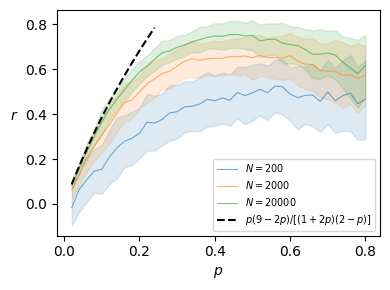

In [15]:
Ns = [200, 2000, 20000]
ps = np.linspace(0.02, 0.8, 40)
trials = 100

fig, ax = plt.subplots(figsize=(4, 3))

for i, N in enumerate(Ns):
    means, stds = [], []
    for p in ps:
        vals = [nx.degree_assortativity_coefficient(model(N, p)) for _ in range(trials)]
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    means, stds = np.array(means), np.array(stds)

    ax.fill_between(ps, means - stds, means + stds, color=f'C{i}', alpha=0.15)
    ax.plot(ps, means, '-', color=f'C{i}', lw=0.8, alpha=0.6, label=f'$N={N}$')

pp = np.linspace(0.02, 0.24, 200)
ax.plot(pp, pp * (9 - 2 * pp) / ((1 + 2 * pp) * (2 - pp)), '--', color='black', lw=1.5, label=r'$p(9-2p)/[(1+2p)(2-p)]$')

ax.set_xlabel('$p$')
ax.set_ylabel('$r$', rotation=0, labelpad=8)
ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig('figures/assortativity.pdf')
plt.show()

## Average shortest-path distance

Simulated mean shortest-path distance (as a function of $N$) vs the prediction

$$\ell = \gamma_N \frac{N+1}{N-1}, \quad \gamma_N = 2\left[(2p-1)(H_N - 1) + (2-3p)\left(H_{N+1} - \tfrac{3}{2}\right)\right] \sim 2(1-p)\ln N.$$

$N \in \{50, 100, 200, 500, 1000, 2000\}$, $p \in \{0.0, 0.1, 0.3, 0.5\}$, 200 trials each. Plot is log-scaled on the $x$-axis.

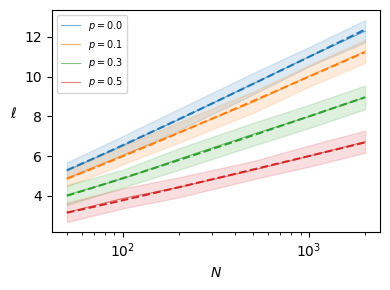

In [16]:
Ns = [50, 100, 200, 500, 1000, 2000]
ps = [0.0, 0.1, 0.3, 0.5]
trials = 200

fig, ax = plt.subplots(figsize=(4, 3))

for i, p in enumerate(ps):
    means, stds = [], []
    for N in Ns:
        vals = [nx.average_shortest_path_length(model(N, p)) for _ in range(trials)]
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    means, stds = np.array(means), np.array(stds)
    ax.fill_between(Ns, means - stds, means + stds, color=f'C{i}', alpha=0.15)
    ax.plot(Ns, means, '-', color=f'C{i}', lw=0.8, alpha=0.6, label=f'$p={p}$')

N = np.arange(50, 2000)
for i, p in enumerate([0.0, 0.1, 0.3, 0.5]):
    ax.plot(N, [ell_theory(N, p) for N in N], '--', color=f'C{i}', lw=1.5)

ax.set_xscale('log')
ax.set_xlabel('$N$')
ax.set_ylabel(r'$\ell$', rotation=0, labelpad=8)
ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig('figures/distance.pdf')
plt.show()

## Consensus timescale $\tau = 1/\lambda_2$

Simulated consensus timescale (as a function of $N$) vs the bounds:

$$\tau = O(N\log N) \text{ at } p=0, \qquad \tau = 1/N \text{ at } p=1.$$

$N \in \{50, 100, 200, 500, 1000, 2000\}$, $p \in \{0.0, 0.1, 0.5, 0.9, 1\}$, 200 trials each. Plot is log-log scaled.

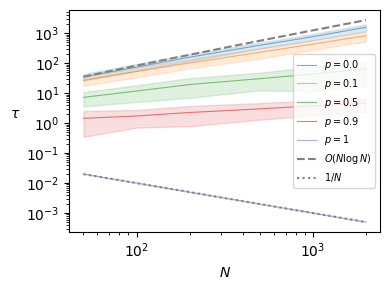

In [19]:
Ns = [50, 100, 200, 500, 1000, 2000]
ps = [0.0, 0.1, 0.5, 0.9, 1]
trials = 200

fig, ax = plt.subplots(figsize=(4, 3))

sim_data = {}
for i, p in enumerate(ps):
    means, stds = [], []
    for N in Ns:
        vals = []
        for _ in range(trials):
            G = model(N, p)
            L = nx.laplacian_matrix(G).toarray().astype(float)
            lam2 = np.linalg.eigvalsh(L)[1]
            vals.append(1.0 / lam2)
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    means, stds = np.array(means), np.array(stds)
    sim_data[p] = means

    ax.fill_between(Ns, means - stds, means + stds, color=f'C{i}', alpha=0.15)
    ax.plot(Ns, means, '-', color=f'C{i}', lw=0.8, alpha=0.6, label=f'$p={p}$')

N = np.linspace(50, 2000, 200)

c = max(sim_data[0.0][i] / (Ns[i] * np.log(Ns[i])) for i in range(len(Ns)))
ax.plot(N, c * N * np.log(N), '--', color='gray', lw=1.5, label=r'$O(N \log N)$')

ax.plot(N, 1.0 / N, ':', color='gray', lw=1.5, label=r'$1/N$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$N$')
ax.set_ylabel(r'$\tau$', rotation=0, labelpad=8)
ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig('figures/spectral_gap.pdf')
plt.show()